In [11]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# 1. 加载原始数据
file_path = r"D:\code\python\ML\Project\air+quality\AirQualityUCI.csv"
df = pd.read_csv(file_path, sep=';', decimal=',')

# 2. 基础清洗（删除全空行列，统一缺失值标记）
df = df.dropna(how='all', axis=1).dropna(how='all', axis=0)
df.replace(-200, np.nan, inplace=True)

# 3. 特征工程：时间维度提取
df['DateTime'] = pd.to_datetime(df['Date'] + ' ' + df['Time'], format='%d/%m/%Y %H.%M.%S')
df['Hour'] = df['DateTime'].dt.hour
df['Month'] = df['DateTime'].dt.month
df['DayOfWeek'] = df['DateTime'].dt.dayofweek
# 对小时进行独热编码（空气质量受小时影响显著）
df = pd.get_dummies(df, columns=['Hour'], prefix='H')

# 4. 记录缺失状态（在插值前操作，保留原始缺失信息作为特征）
df['CO_is_missing'] = df['CO(GT)'].isna().astype(int)

# 5. 准备数值特征列
# 排除非数值的时间列
df_numeric = df.drop(['Date', 'Time', 'DateTime'], axis=1)
cols_to_scale = ['CO(GT)', 'PT08.S1(CO)', 'NMHC(GT)', 'C6H6(GT)', 'PT08.S2(NMHC)', 
                 'NOx(GT)', 'PT08.S3(NOx)', 'NO2(GT)', 'PT08.S4(NO2)', 'PT08.S5(O3)', 'T', 'RH', 'AH']

# 6. 三段式顺序切分 (Train: 70%, Val: 15%, Test: 15%)
# 注意：shuffle=False 是时间序列处理的生命线
train_val_df, test_df = train_test_split(df_numeric, test_size=0.15, shuffle=False)
train_df, val_df = train_test_split(train_val_df, test_size=0.176, shuffle=False) # 0.85 * 0.176 ≈ 0.15

# 7. 缺失值填补 (Interpolation)
# 核心逻辑：每一段独立插值，避免未来信息回流
train_df = train_df.interpolate(method='linear', limit_direction='both')
val_df = val_df.interpolate(method='linear', limit_direction='both')
test_df = test_df.interpolate(method='linear', limit_direction='both')

# 8. 数据标准化 (Standardization)
scaler = StandardScaler()

# 重点：只在训练集上进行 fit，学习训练集的均值和标准差
scaler.fit(train_df[cols_to_scale])

# 将学习到的规则应用到三部分数据中
train_df[cols_to_scale] = scaler.transform(train_df[cols_to_scale])
val_df[cols_to_scale] = scaler.transform(val_df[cols_to_scale])
test_df[cols_to_scale] = scaler.transform(test_df[cols_to_scale])

# 9. 导出处理后的数据集
output_dir = r"D:\code\python\ML\Project\air+quality\\"
train_df.to_csv(output_dir + "AirQuality_Train.csv", index=False)
val_df.to_csv(output_dir + "AirQuality_Val.csv", index=False)
test_df.to_csv(output_dir + "AirQuality_Test.csv", index=False)

print("--- 预处理完成 ---")
print(f"训练集样本数: {len(train_df)}")
print(f"验证集样本数: {len(val_df)}")
print(f"测试集样本数: {len(test_df)}")
print(f"所有数据已保存至: {output_dir}")

# 展示预处理后的前几行
print("\n训练集预览：")
print(train_df[cols_to_scale].head())

--- 预处理完成 ---
训练集样本数: 6553
验证集样本数: 1400
测试集样本数: 1404
所有数据已保存至: D:\code\python\ML\Project\air+quality\\

训练集预览：
     CO(GT)  PT08.S1(CO)  NMHC(GT)  C6H6(GT)  PT08.S2(NMHC)   NOx(GT)  \
0  0.322376     1.198293 -1.327128  0.148118       0.301864 -0.216082   
1 -0.101855     0.888277 -1.755875 -0.176375      -0.037921 -0.556798   
2  0.039555     1.389773 -2.026662 -0.228294      -0.097663 -0.405368   
3  0.039555     1.271237 -2.116925 -0.202334      -0.064058 -0.183633   
4 -0.384676     0.797096 -2.444126 -0.552786      -0.482254 -0.405368   

   PT08.S3(NOx)   NO2(GT)  PT08.S4(NO2)  PT08.S5(O3)         T        RH  \
0      0.792431  0.393814      0.387616     0.692832 -1.058639  0.062195   
1      1.261445 -0.142932     -0.072621    -0.093136 -1.097895 -0.006969   
2      1.126306  0.419373     -0.086463     0.177704 -1.281089  0.356140   
3      0.935520  0.623848      0.013890     0.520237 -1.398856  0.701957   
4      1.384661  0.470492     -0.311391     0.273295 -1.372685  0.6789

In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split


file_path = r"D:\code\python\ML\Project\air+quality\AirQualityUCI.csv"
df = pd.read_csv(file_path, sep=';', decimal=',')

df = df.dropna(how='all', axis=1).dropna(how='all', axis=0)
df.replace(-200, np.nan, inplace=True)

df['DateTime'] = pd.to_datetime(df['Date'] + ' ' + df['Time'], format='%d/%m/%Y %H.%M.%S')
df['Hour'] = df['DateTime'].dt.hour
df['Month'] = df['DateTime'].dt.month
df['DayOfWeek'] = df['DateTime'].dt.dayofweek

df = pd.get_dummies(df, columns=['Hour'], prefix='H')

df['CO_is_missing'] = df['CO(GT)'].isna().astype(int)

df_numeric = df.drop(['Date', 'Time', 'DateTime'], axis=1)
cols_to_scale = ['CO(GT)', 'PT08.S1(CO)', 'NMHC(GT)', 'C6H6(GT)', 'PT08.S2(NMHC)', 
                 'NOx(GT)', 'PT08.S3(NOx)', 'NO2(GT)', 'PT08.S4(NO2)', 'PT08.S5(O3)', 'T', 'RH', 'AH']

train_val_df, test_df = train_test_split(df_numeric, test_size=0.15, shuffle=False)
train_df, val_df = train_test_split(train_val_df, test_size=0.176, shuffle=False) # 0.85 * 0.176 ≈ 0.15

train_df = train_df.interpolate(method='linear', limit_direction='both')
val_df = val_df.interpolate(method='linear', limit_direction='both')
test_df = test_df.interpolate(method='linear', limit_direction='both')


output_dir = r"D:\code\python\ML\Project\air+quality\\"
train_df.to_csv(output_dir + "AirQuality_Train_real.csv", index=False)
val_df.to_csv(output_dir + "AirQuality_Val_real.csv", index=False)
test_df.to_csv(output_dir + "AirQuality_Test_real.csv", index=False)

print("--- 预处理完成 ---")
print(f"训练集样本数: {len(train_df)}")
print(f"验证集样本数: {len(val_df)}")
print(f"测试集样本数: {len(test_df)}")
print(f"所有数据已保存至: {output_dir}")

# 展示预处理后的前几行
print("\n训练集预览：")
print(train_df[cols_to_scale].head())

--- 预处理完成 ---
训练集样本数: 6553
验证集样本数: 1400
测试集样本数: 1404
所有数据已保存至: D:\code\python\ML\Project\air+quality\\

训练集预览：
   CO(GT)  PT08.S1(CO)  NMHC(GT)  C6H6(GT)  PT08.S2(NMHC)  NOx(GT)  \
0     2.6       1360.0     150.0      11.9         1046.0    166.0   
1     2.0       1292.0     112.0       9.4          955.0    103.0   
2     2.2       1402.0      88.0       9.0          939.0    131.0   
3     2.2       1376.0      80.0       9.2          948.0    172.0   
4     1.6       1272.0      51.0       6.5          836.0    131.0   

   PT08.S3(NOx)  NO2(GT)  PT08.S4(NO2)  PT08.S5(O3)     T    RH      AH  
0        1056.0    113.0        1692.0       1268.0  13.6  48.9  0.7578  
1        1174.0     92.0        1559.0        972.0  13.3  47.7  0.7255  
2        1140.0    114.0        1555.0       1074.0  11.9  54.0  0.7502  
3        1092.0    122.0        1584.0       1203.0  11.0  60.0  0.7867  
4        1205.0    116.0        1490.0       1110.0  11.2  59.6  0.7888  


In [12]:
import joblib

# 保存那个已经在训练集上 fit 过的 scaler
joblib.dump(scaler, 'air_quality_scaler.pkl')

['air_quality_scaler.pkl']

2D：mouth
3，4月聚类明显，其余无明显聚类

正在计算 t-SNE,请稍候约十几秒...


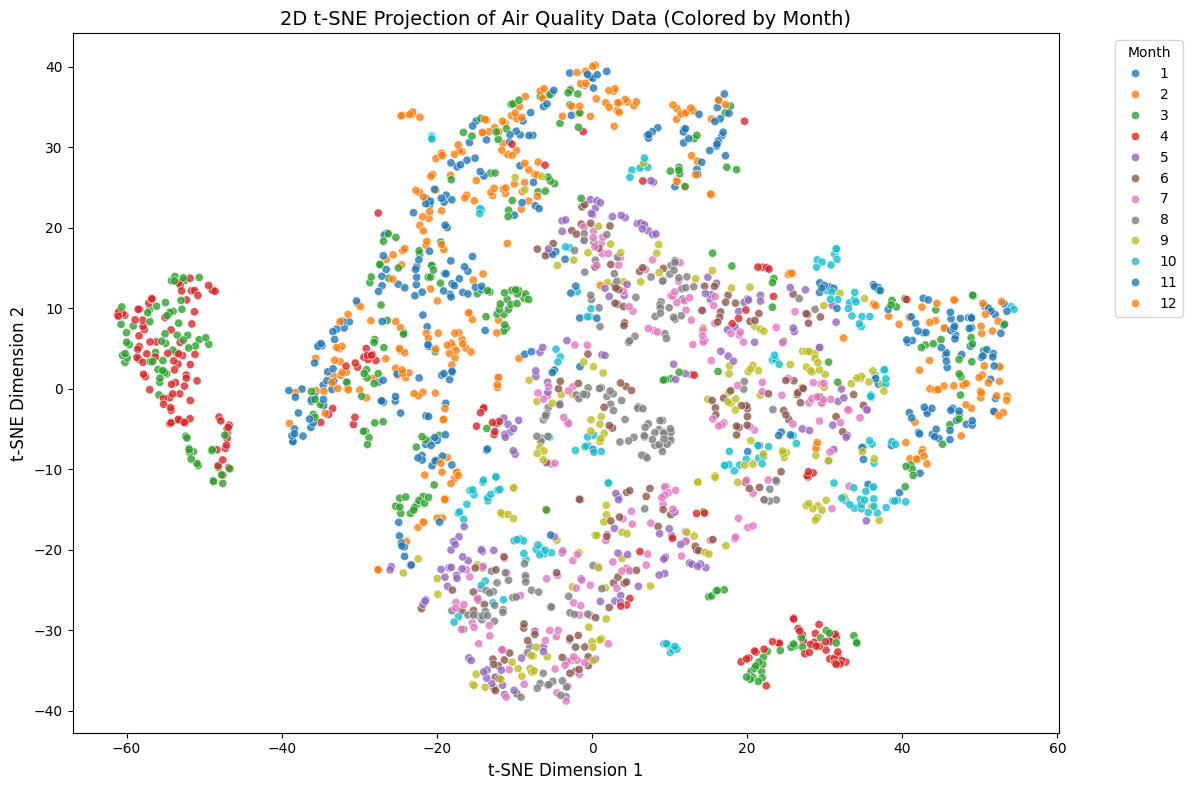

In [3]:
import seaborn as sns
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

# 1. 读取你刚刚预处理完的干净数据
file_path = r"D:\code\python\ML\Project\air+quality\AirQuality_Fully_Preprocessed.csv"
df = pd.read_csv(file_path)

# 2. 【关键】随机抽样 2000 条数据以加速 t-SNE 计算
df_sampled = df.sample(n=2000, random_state=42)

# 3. 确定特征 (X) 和 颜色标签 (y)
# 我们提取 'Month' 作为颜色标签，其余所有列作为降维的特征输入
y = df_sampled['Month']
X = df_sampled.drop(columns=['Month']) 

# 4. 初始化并运行 t-SNE
# perplexity (困惑度) 是 t-SNE 最重要的参数，通常设为 30
print("正在计算 t-SNE,请稍候约十几秒...")
tsne = TSNE(n_components=2, perplexity=40, random_state=42, init='pca', learning_rate='auto')
tsne_results = tsne.fit_transform(X)

# 5. 将结果转换为 DataFrame 以便使用 seaborn 画图
df_tsne = pd.DataFrame({
    't-SNE Dimension 1': tsne_results[:, 0],
    't-SNE Dimension 2': tsne_results[:, 1],
    'Month': y.values
})

# 6. 绘制散点图 (Scatter Plot)
plt.figure(figsize=(12, 8))
# 使用 'Month' 作为颜色区分 (hue)，采用明亮的调色板
scatter = sns.scatterplot(
    x="t-SNE Dimension 1", y="t-SNE Dimension 2",
    hue="Month",
    palette="tab10",  # 使用适合多分类的调色板
    data=df_tsne,
    legend="full",
    alpha=0.8
)

plt.title('2D t-SNE Projection of Air Quality Data (Colored by Month)', fontsize=14)
plt.xlabel('t-SNE Dimension 1', fontsize=12)
plt.ylabel('t-SNE Dimension 2', fontsize=12)
# 将图例移到图表外侧以免遮挡数据
plt.legend(title='Month', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

2D: NO2 + Daytime
无明显聚合

参与降维的特征共 12 个: ['CO(GT)', 'PT08.S1(CO)', 'C6H6(GT)', 'PT08.S2(NMHC)', 'NOx(GT)', 'PT08.S3(NOx)', 'NO2(GT)', 'PT08.S4(NO2)', 'PT08.S5(O3)', 'T', 'RH', 'AH']
正在计算 t-SNE (Perplexity=200, Iterations=3000)...


C:\Users\36024\AppData\Local\Temp\ipykernel_18048\2410047751.py:89: MatplotlibDeprecationWarning: Unable to determine Axes to steal space for Colorbar. Using gca(), but will raise in the future. Either provide the *cax* argument to use as the Axes for the Colorbar, provide the *ax* argument to steal space from it, or add *mappable* to an Axes.
  plt.colorbar(sm, label='Normalized PT08.S4(NO2) Reading')


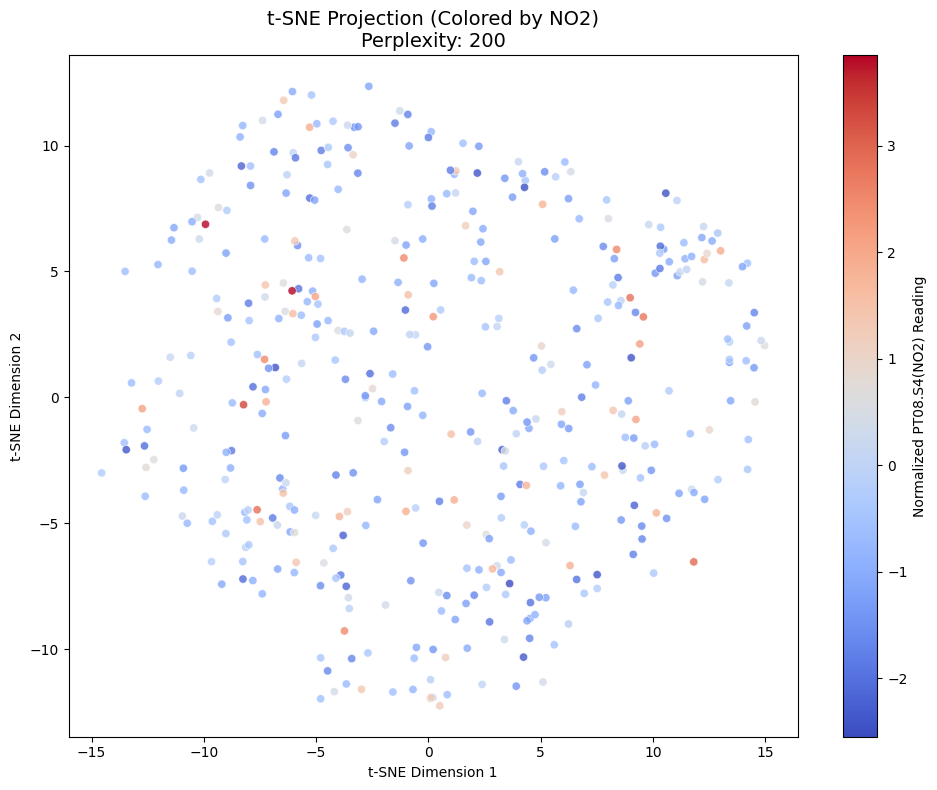

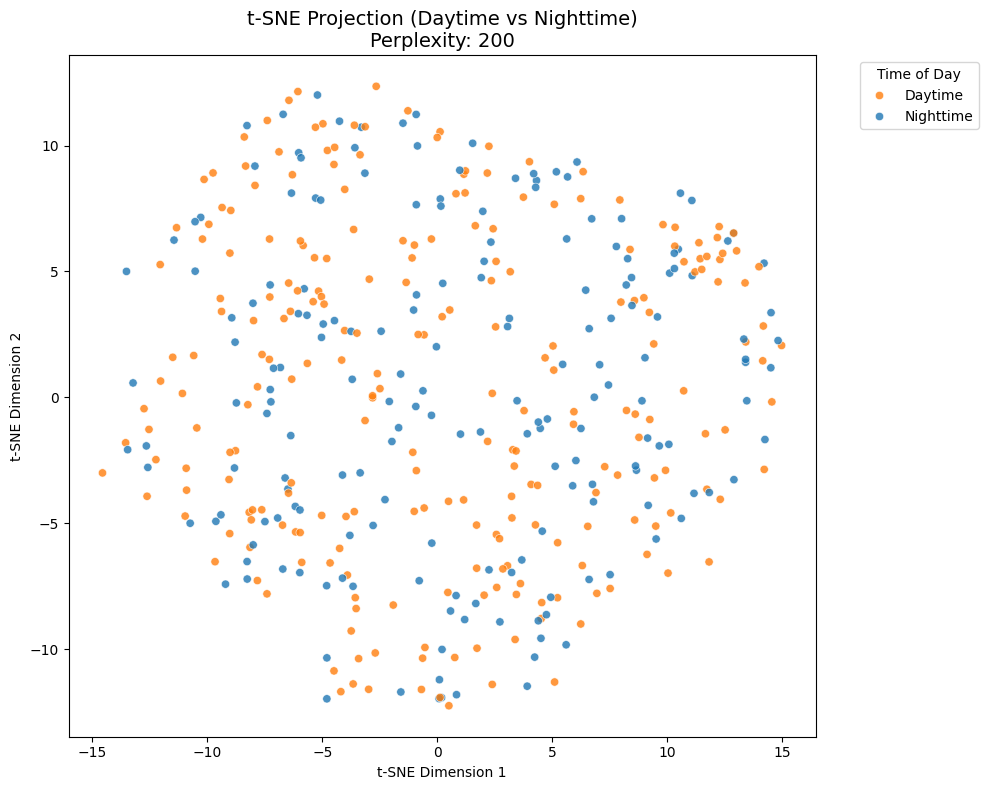

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE

# ==========================================
# 🎯 调参中心 (Configuration)
# 每次调参只需要修改这里的值，不要动下面的主体代码
# ==========================================
CONFIG = {
    # 1. 数据参数
    'file_path': r"D:\code\python\ML\Project\air+quality\AirQuality_Fully_Preprocessed.csv",
    'n_samples': 2000,               # 采样数。如果想看全貌可以调到 4000，但计算会变慢
    
    # 2. 特征工程参数
    # 在这里填入你想踢出降维计算的连续特征。
    # 强烈建议踢出 'NMHC(GT)'，因为它的原始数据缺失率高达 90%
    'exclude_features': ['NMHC(GT)'], 
    
    # 3. t-SNE 核心超参数 (针对“点太散”的问题进行调整)
    'tsne_perplexity': 200,           # 【关键】困惑度。默认 30-40。点太散时，增加到 80-100，让算法关注更大的簇
    'tsne_learning_rate': 200,       # 学习率。设为具体数值(如 200)通常比 'auto' 效果更稳定
    'tsne_n_iter': 3000,             # 迭代次数。默认 1000。点未收敛时增加到 2000-3000
    'tsne_init': 'pca',              # 初始化方式，保持 pca 即可
    'random_state': 42               # 随机种子，保证每次跑出来的图一样
}

# ==========================================
# 1. 数据加载与基础准备
# ==========================================
df = pd.read_csv(CONFIG['file_path'])

# 随机抽样
df_sampled = df.sample(n=CONFIG['n_samples'], random_state=CONFIG['random_state']).copy()

# ==========================================
# 2. 特征提取 (X)
# ==========================================
# 原始所有的物理化学连续变量
all_physical_cols = [
    'CO(GT)', 'PT08.S1(CO)', 'NMHC(GT)', 'C6H6(GT)', 'PT08.S2(NMHC)', 
    'NOx(GT)', 'PT08.S3(NOx)', 'NO2(GT)', 'PT08.S4(NO2)', 'PT08.S5(O3)', 
    'T', 'RH', 'AH'
]

# 根据 CONFIG 自动剔除不需要的特征
final_cols = [col for col in all_physical_cols if col not in CONFIG['exclude_features']]
print(f"参与降维的特征共 {len(final_cols)} 个: {final_cols}")

X = df_sampled[final_cols]

# ==========================================
# 3. 运行强化版 t-SNE
# ==========================================
print(f"正在计算 t-SNE (Perplexity={CONFIG['tsne_perplexity']}, Iterations={CONFIG['tsne_n_iter']})...")
tsne = TSNE(
    n_components=2, 
    perplexity=CONFIG['tsne_perplexity'], 
    learning_rate=CONFIG['tsne_learning_rate'],
    n_iter=CONFIG['tsne_n_iter'],
    init=CONFIG['tsne_init'],
    random_state=CONFIG['random_state']
)
tsne_results = tsne.fit_transform(X)

df_tsne = pd.DataFrame({
    't-SNE Dimension 1': tsne_results[:, 0],
    't-SNE Dimension 2': tsne_results[:, 1]
})

# ==========================================
# 4. 图表 1：按照 NO2 传感器读数着色
# ==========================================
y_no2 = df_sampled['PT08.S4(NO2)']
df_tsne['NO2_Level'] = y_no2

plt.figure(figsize=(10, 8))
scatter_no2 = sns.scatterplot(
    x="t-SNE Dimension 1", y="t-SNE Dimension 2",
    hue="NO2_Level", palette="coolwarm", data=df_tsne, alpha=0.8
)

plt.title(f"t-SNE Projection (Colored by NO2)\nPerplexity: {CONFIG['tsne_perplexity']}", fontsize=14)
norm = plt.Normalize(y_no2.min(), y_no2.max())
sm = plt.cm.ScalarMappable(cmap="coolwarm", norm=norm)
sm.set_array([])
scatter_no2.get_legend().remove()
plt.colorbar(sm, label='Normalized PT08.S4(NO2) Reading')
plt.tight_layout()
plt.show()

# ==========================================
# 5. 图表 2：按照 白天 VS 黑夜 着色
# ==========================================
hour_series = df_sampled.filter(like='H_').idxmax(axis=1).str.replace('H_', '').astype(int)

def get_day_period(hour):
    return 'Daytime' if 7 <= hour <= 19 else 'Nighttime'

df_tsne['TimeOfDay'] = hour_series.apply(get_day_period)

plt.figure(figsize=(10, 8))
sns.scatterplot(
    x="t-SNE Dimension 1", y="t-SNE Dimension 2",
    hue="TimeOfDay", palette={"Daytime": "#ff7f0e", "Nighttime": "#1f77b4"}, 
    data=df_tsne, alpha=0.8
)

plt.title(f"t-SNE Projection (Daytime vs Nighttime)\nPerplexity: {CONFIG['tsne_perplexity']}", fontsize=14)
plt.legend(title='Time of Day', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

NO2
进行颜色映射时，可以观察到明显的长尾分布现象。图中绝大部分区域属于正常基线水平（浅色），而极少数的高污染“爆表”事件（深色）集中在流形的特定边缘地带，这与交通拥堵或极端天气的偶发性相吻合。

正在计算 3D t-SNE (这会比 2D 稍微慢一点)...


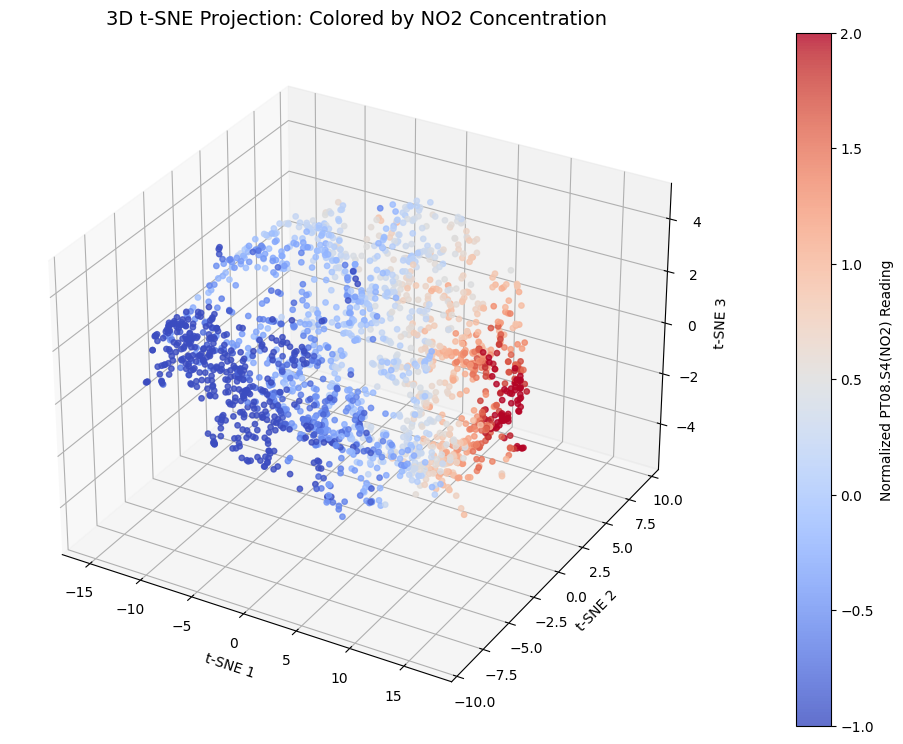

In [ ]:
import pandas as pd
import numpy as np
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt


file_path = r"D:\code\python\ML\Project\air+quality\AirQuality_Fully_Preprocessed.csv"
df = pd.read_csv(file_path)
df_sampled = df.sample(n=2000, random_state=42).copy()

# 提取物理特征 (继续踢出缺失严重的 NMHC)
physical_cols = [
    'CO(GT)', 'PT08.S1(CO)', 'C6H6(GT)', 'PT08.S2(NMHC)', 
    'NOx(GT)', 'PT08.S3(NOx)', 'NO2(GT)', 'PT08.S4(NO2)', 'PT08.S5(O3)'
]
X = df_sampled[physical_cols]


print("正在计算 3D t-SNE (这会比 2D 稍微慢一点)...")
tsne_3d = TSNE(
    n_components=3,      # 【关键改变】目标维度设为 3
    perplexity=50,       # 降回合理的困惑度
    learning_rate=200,
    n_iter=2000,
    init='pca',
    random_state=42
)
tsne_results_3d = tsne_3d.fit_transform(X)

# 将 3D 坐标存入 DataFrame
df_tsne_3d = pd.DataFrame({
    'TSNE_1': tsne_results_3d[:, 0],
    'TSNE_2': tsne_results_3d[:, 1],
    'TSNE_3': tsne_results_3d[:, 2],
    'NO2_Level': df_sampled['PT08.S4(NO2)'], # 用于渐变着色
})

# ==========================================
# 3. 使用 Plotly 绘制可旋转的 3D 散点图
# ==========================================

# --- 视角 1：按 NO2 浓度着色 (连续渐变) ---
fig1 = plt.figure(figsize=(12, 9))
# projection='3d' 告诉 matplotlib 这是一个三维图
ax1 = fig1.add_subplot(111, projection='3d')

# 绘制 3D 散点
scatter1 = ax1.scatter(
    df_tsne_3d['TSNE_1'], 
    df_tsne_3d['TSNE_2'], 
    df_tsne_3d['TSNE_3'],
    c=df_tsne_3d['NO2_Level'], # 颜色映射值
    cmap='coolwarm', 
    s=15, 
    alpha=0.8,
    vmin=-1.0,     # 设定蓝色的底线
    vmax=2.0                # 透明度
)

# 添加颜色条和标签
fig1.colorbar(scatter1, ax=ax1, label='Normalized PT08.S4(NO2) Reading', pad=0.1)
ax1.set_title('3D t-SNE Projection: Colored by NO2 Concentration', fontsize=14)
ax1.set_xlabel('t-SNE 1')
ax1.set_ylabel('t-SNE 2')
ax1.set_zlabel('t-SNE 3')
plt.show()

T，Traffic Period
流形连续性 (Manifold Continuity): 从 t-SNE 的三维/二维投影中观察到，数据并没有聚集成几个完全孤立的岛屿，而是呈现出连续的流形结构（如心形或带状）。这反映了空气质量数据作为时间序列的本质——物理环境的演变是平滑过渡的。

正在运行 3D t-SNE，请稍候...


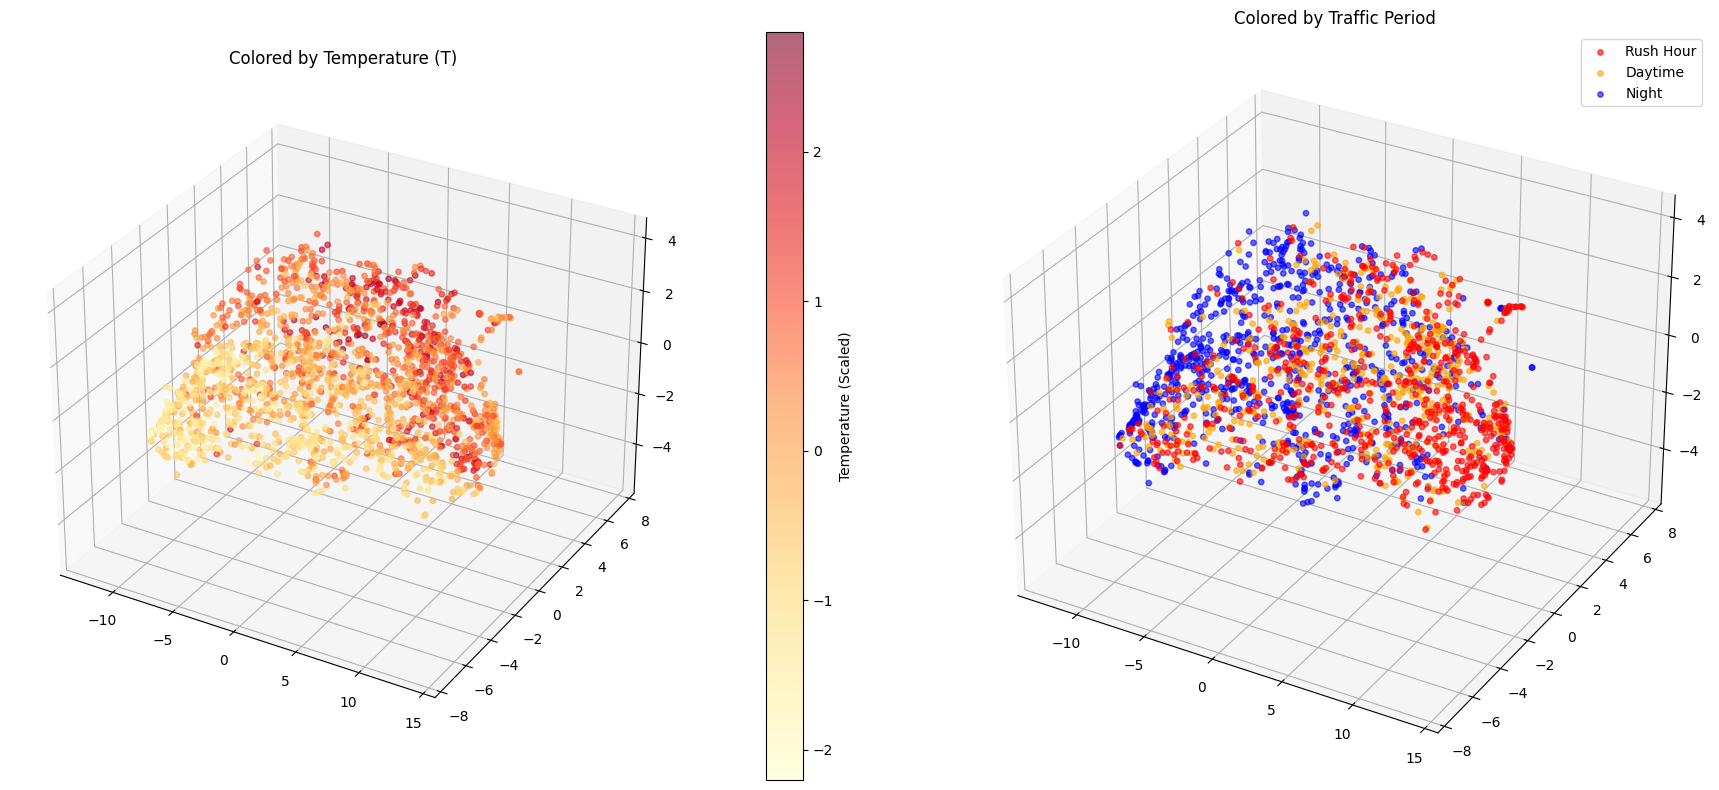

In [ ]:
import pandas as pd
import numpy as np
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

# ==========================================
# 1. 配置与数据加载
# ==========================================
# 请确保使用你之前生成的那个“包含原始数据和标准化数据”的 CSV
file_path = r"D:\code\python\ML\Project\air+quality\AirQuality_Fully_Preprocessed.csv"
df = pd.read_csv(file_path)

# 采样，防止计算过慢
n_samples = 2000
df_sampled = df.sample(n=n_samples, random_state=42).copy()

# 【关键点】定义两组特征集进行对比
# 核心污染特征（剔除了 T, RH, AH 干扰）
pollution_only_cols = [
    'CO(GT)', 'PT08.S1(CO)', 'C6H6(GT)', 'PT08.S2(NMHC)', 
    'NOx(GT)', 'PT08.S3(NOx)', 'NO2(GT)', 'PT08.S4(NO2)', 'PT08.S5(O3)'
]
# 全特征（包含气象干扰）
all_features_cols = pollution_only_cols + ['T', 'RH', 'AH']

# --- 你可以在这里切换 X 的选择 ---
X = df_sampled[pollution_only_cols] # 建议先试这个，看看去掉了温度后颜色是否聚拢

# ==========================================
# 2. 运行 3D t-SNE
# ==========================================
print("正在运行 3D t-SNE, 请稍候...")
tsne = TSNE(
    n_components=3,
    perplexity=75,       # 回到中等水平
    learning_rate=100,
    n_iter=3000,         # 增加迭代次数让它跑得更开
    init='pca',
    random_state=42
)
tsne_results = tsne.fit_transform(X)

# 还原小时并分类（用于视角2对比）
hour_series = df_sampled.filter(like='H_').idxmax(axis=1).str.replace('H_', '').astype(int)
def categorize_time(hour):
    if 7 <= hour <= 10 or 17 <= hour <= 20: return 'Rush Hour'
    elif 11 <= hour <= 16: return 'Daytime'
    else: return 'Night'

# 构建绘图数据框
df_plot = pd.DataFrame({
    'X': tsne_results[:, 0],
    'Y': tsne_results[:, 1],
    'Z': tsne_results[:, 2],
    'Temp': df_sampled['T'],          # 用于温度映射
    'Humidity': df_sampled['RH'],    # 用于湿度映射
    'Traffic': hour_series.apply(categorize_time)
})

# ==========================================
# 3. 绘图对比：验证“天气主导”假说
# ==========================================

# --- 视角 1：按温度着色 (验证是否有天气聚类) ---
fig = plt.figure(figsize=(18, 8))

ax1 = fig.add_subplot(121, projection='3d')
sc1 = ax1.scatter(df_plot['X'], df_plot['Y'], df_plot['Z'], 
                  c=df_plot['Temp'], cmap='YlOrRd', s=15, alpha=0.6)
fig.colorbar(sc1, ax=ax1, label='Temperature (Scaled)', pad=0.1)
ax1.set_title('Colored by Temperature (T)')

# --- 视角 2：按交通时段着色 (观察是否有逻辑改进) ---
ax2 = fig.add_subplot(122, projection='3d')
colors = {'Rush Hour': 'red', 'Daytime': 'orange', 'Night': 'blue'}
for status, color in colors.items():
    subset = df_plot[df_plot['Traffic'] == status]
    ax2.scatter(subset['X'], subset['Y'], subset['Z'], 
                c=color, label=status, s=15, alpha=0.6)

ax2.legend()
ax2.set_title('Colored by Traffic Period')

plt.tight_layout()
plt.show()

NOx
当使用特定的污染指标进行颜色映射时，可以观察到明显的长尾分布现象。图中绝大部分区域属于正常基线水平（浅色），而极少数的高污染“爆表”事件（深色）集中在流形的特定边缘地带，这与交通拥堵或极端天气的偶发性相吻合。

正在计算 3D t-SNE (这会比 2D 稍微慢一点)...


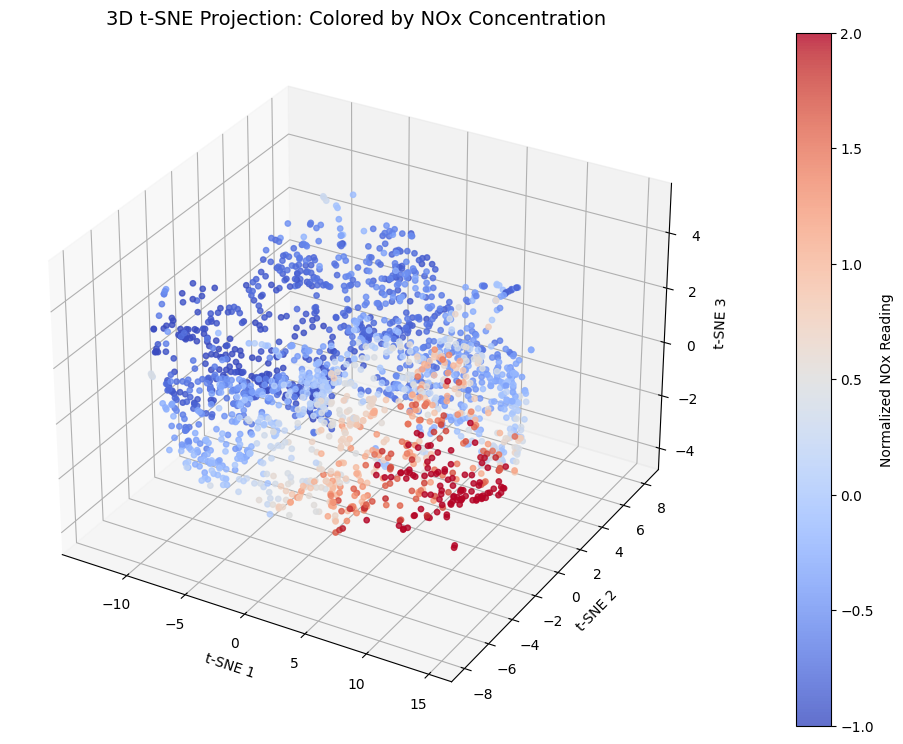

In [39]:
import pandas as pd
import numpy as np
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt


file_path = r"D:\code\python\ML\Project\air+quality\AirQuality_Fully_Preprocessed.csv"
df = pd.read_csv(file_path)
df_sampled = df.sample(n=2000, random_state=42).copy()

physical_cols = [
    'CO(GT)', 'PT08.S1(CO)', 'C6H6(GT)', 'PT08.S2(NMHC)', 
    'NOx(GT)', 'PT08.S3(NOx)', 'NO2(GT)', 'PT08.S4(NO2)', 'PT08.S5(O3)'
]
X = df_sampled[physical_cols]


# 运行 3D t-SNE
print("正在计算 3D t-SNE (这会比 2D 稍微慢一点)...")
tsne_3d = TSNE(
    n_components=3,      
    perplexity=70,       
    learning_rate=200,
    n_iter=3000,
    init='pca',
    random_state=42
)
tsne_results_3d = tsne_3d.fit_transform(X)

# 将 3D 坐标存入 DataFrame
df_tsne_3d = pd.DataFrame({
    'TSNE_1': tsne_results_3d[:, 0],
    'TSNE_2': tsne_results_3d[:, 1],
    'TSNE_3': tsne_results_3d[:, 2],
    'NOx_Level': df_sampled['NOx(GT)'], 
})


fig1 = plt.figure(figsize=(12, 9))
ax1 = fig1.add_subplot(111, projection='3d')

scatter1 = ax1.scatter(
    df_tsne_3d['TSNE_1'], 
    df_tsne_3d['TSNE_2'], 
    df_tsne_3d['TSNE_3'],
    c=df_tsne_3d['NOx_Level'], 
    cmap='coolwarm', 
    s=15, 
    alpha=0.8,
    vmin=-1.0,    
    vmax=2.0              
)

fig1.colorbar(scatter1, ax=ax1, label='Normalized NOx Reading', pad=0.1)
ax1.set_title('3D t-SNE Projection: Colored by NOx Concentration', fontsize=14)
ax1.set_xlabel('t-SNE 1')
ax1.set_ylabel('t-SNE 2')
ax1.set_zlabel('t-SNE 3')
plt.show()

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
import itertools
import warnings
from sklearn import metrics
from sklearn.manifold import TSNE
from sklearn.metrics import davies_bouldin_score, calinski_harabasz_score

warnings.filterwarnings('ignore') 

K-means 沿着综合污染指数（PCA 1），把连续的空气质量强行划分成了三个等级。

--- 聚类任务评估结果 ---
1. 轮廓系数 (Silhouette): 0.3047 (越大越好)
2. DB指数 (Davies-Bouldin): 1.0901 (越小越好)
3. CH指数 (Calinski-Harabasz): 1624.0231 (越大越好)


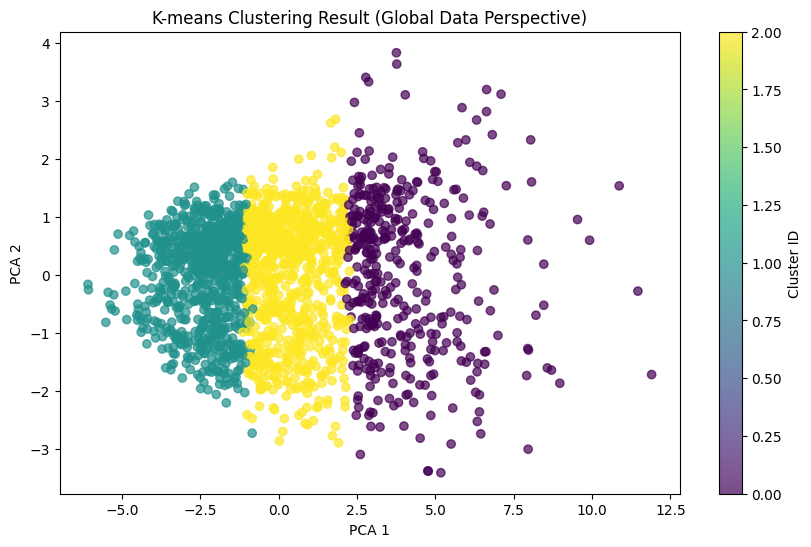

In [2]:
# 1. 加载全量预处理后的数据
file_path = r"D:\code\python\ML\Project\air+quality\AirQuality_Fully_Preprocessed.csv"
df = pd.read_csv(file_path)

# 为了绘图效率和指标计算速度，采样 2000 条 (代表全量分布)
df_sampled = df.sample(n=2000, random_state=42).copy()

# 2. 筛选物理/化学特征 (剔除 T, RH 等气象干扰)
physical_cols = [
    'CO(GT)', 'PT08.S1(CO)', 'C6H6(GT)', 'PT08.S2(NMHC)', 
    'NOx(GT)', 'PT08.S3(NOx)', 'NO2(GT)', 'PT08.S4(NO2)', 'PT08.S5(O3)'
]
X = df_sampled[physical_cols]

# 必须执行归一化
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. 运行 K-means (设定 K=3)
kmeans = KMeans(n_clusters=3, init='k-means++', n_init=10, random_state=42)
labels = kmeans.fit_predict(X_scaled)

# 4. 多指标评估 (Rubric 要求)
sil = silhouette_score(X_scaled, labels)
db = davies_bouldin_score(X_scaled, labels)
ch = calinski_harabasz_score(X_scaled, labels)

print(f"--- 聚类任务评估结果 ---")
print(f"1. 轮廓系数 (Silhouette): {sil:.4f} (越大越好)")
print(f"2. DB指数 (Davies-Bouldin): {db:.4f} (越小越好)")
print(f"3. CH指数 (Calinski-Harabasz): {ch:.4f} (越大越好)")

# 5. 可视化 (PCA 降维)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(10, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap='viridis', alpha=0.7)
plt.colorbar(scatter, label='Cluster ID')
plt.title('K-means Clustering Result (Global Data Perspective)')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.show()

K-means 早高峰和空气污染（筛选后的四个核心污染特征）

正在寻找最优的 K 值...
K=2 时的轮廓系数: 0.5277
K=3 时的轮廓系数: 0.4423
K=4 时的轮廓系数: 0.3906
K=5 时的轮廓系数: 0.3892

🏆 最终选择 K=2，因为它的轮廓系数最高 (0.5277)
对应的 DB 指数 (越低越好): 0.7490


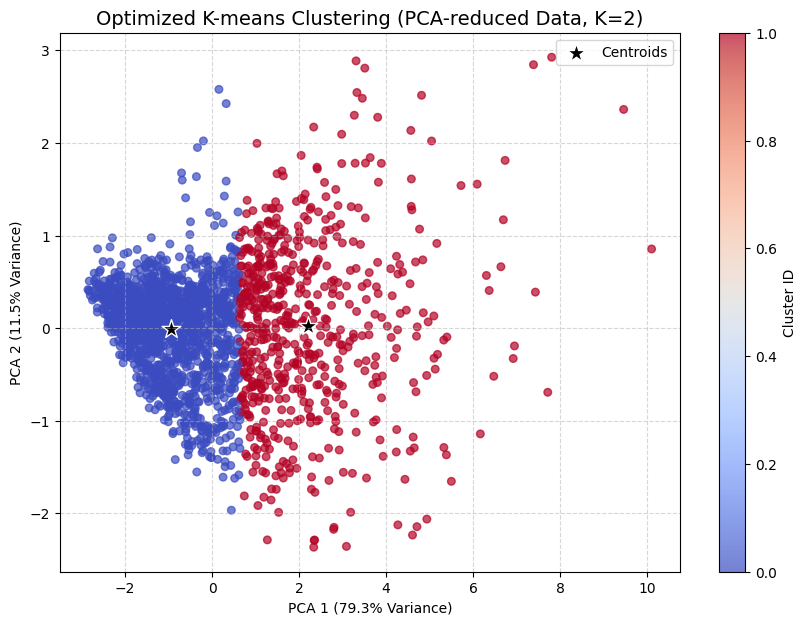


正在进行 t-SNE 降维运算 (由于是非线性计算，可能需要几十秒，请稍候)...


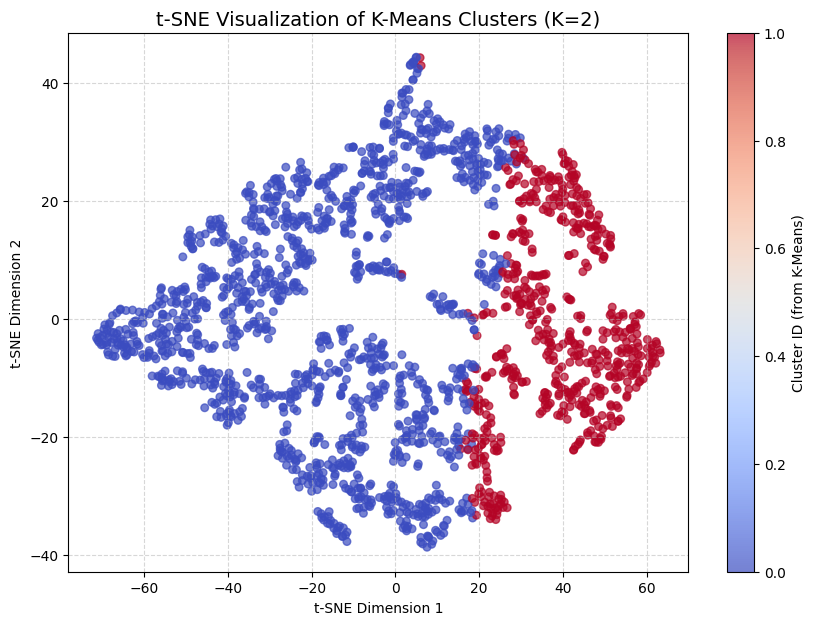

In [4]:
# ==========================================
# 1. 加载数据与精简特征
# ==========================================
file_path = r"D:\code\python\ML\Project\air+quality\AirQuality_Fully_Preprocessed.csv"
df = pd.read_csv(file_path)
df_sampled = df.sample(n=2000, random_state=42).copy()

# 【提分技巧】只保留最具代表性的 4 个核心污染特征，扔掉冗余传感器
core_features = ['CO(GT)', 'NOx(GT)', 'NO2(GT)', 'C6H6(GT)']
X = df_sampled[core_features]

# 标准化
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ==========================================
# 2. 降维提纯 (PCA)
# ==========================================
# 【提分技巧】把 4 维数据降到 2 维，滤除白噪音，让聚类算法只看“主干”
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# ==========================================
# 3. 自动寻找最高分的 K 值
# ==========================================
print("正在寻找最优的 K 值...")
best_k = 2
best_score = -1
best_labels = None
best_kmeans = None

# 测试 K=2 到 K=5
for k in range(2, 6):
    kmeans = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    labels = kmeans.fit_predict(X_pca) # 注意：这里我们在 PCA 后的数据上聚类
    score = silhouette_score(X_pca, labels)
    print(f"K={k} 时的轮廓系数: {score:.4f}")
    
    if score > best_score:
        best_score = score
        best_k = k
        best_labels = labels
        best_kmeans = kmeans

print(f"\n🏆 最终选择 K={best_k}，因为它的轮廓系数最高 ({best_score:.4f})")

# 计算最佳 K 值的其他指标
db_score = davies_bouldin_score(X_pca, best_labels)
print(f"对应的 DB 指数 (越低越好): {db_score:.4f}")

# ==========================================
# 4. 绘制“高分版”完美聚类图
# ==========================================
plt.figure(figsize=(10, 7))

# 这次画出来的图，簇与簇之间的分离度会好很多
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=best_labels, cmap='coolwarm', alpha=0.7, s=30)
plt.colorbar(scatter, label='Cluster ID')

# 画出聚类中心 (用黑色大星星表示)
centers = best_kmeans.cluster_centers_
plt.scatter(centers[:, 0], centers[:, 1], c='black', s=200, marker='*', edgecolors='white', label='Centroids')

plt.title(f'Optimized K-means Clustering (PCA-reduced Data, K={best_k})', fontsize=14)
plt.xlabel(f'PCA 1 ({pca.explained_variance_ratio_[0]:.1%} Variance)')
plt.ylabel(f'PCA 2 ({pca.explained_variance_ratio_[1]:.1%} Variance)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# ==========================================
# 5. 绘制非线性流形图 (t-SNE)
# ==========================================
print("\n正在进行 t-SNE 降维运算 (由于是非线性计算，可能需要几十秒，请稍候)...")

# 初始化 t-SNE
# perplexity (困惑度) 是 t-SNE 的核心参数，通常在 5 到 50 之间。30 是一个很好的默认值。
tsne = TSNE(n_components=2, perplexity=30, n_iter=1000, random_state=42, init='pca')

# 注意：我们用之前标准化后的原始核心特征 X_scaled 来跑 t-SNE，以获取最真实的局部拓扑结构
X_tsne = tsne.fit_transform(X_scaled)

plt.figure(figsize=(10, 7))

# 依然使用 KMeans 算出来的 best_labels 进行着色
scatter_tsne = plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=best_labels, cmap='coolwarm', alpha=0.7, s=30)
plt.colorbar(scatter_tsne, label='Cluster ID (from K-Means)')

plt.title(f't-SNE Visualization of K-Means Clusters (K={best_k})', fontsize=14)
plt.xlabel('t-SNE Dimension 1')
plt.ylabel('t-SNE Dimension 2')

# ⚠️ 注意：这里我们故意没有画“聚类中心（黑星星）”！

plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

K-means 早高峰时间和空气污染几乎不重叠

In [ ]:
# ==========================================
# 1. 准备数据与生成“标准答案” (Ground Truth)
# ==========================================
# 修复后的代码：从 H_0 到 H_23 的列名中还原出具体的小时数字
hour_series = df_sampled.filter(like='H_').idxmax(axis=1).str.replace('H_', '').astype(int)

def categorize_time(hour):
    if 7 <= hour <= 10 or 17 <= hour <= 20:
        return 0  # Rush Hour (早晚高峰)
    elif 11 <= hour <= 16:
        return 1  # Daytime Slump (白天平峰)
    else:
        return 2  # Night/Rest (夜间休息)

# y_true 就是我们的“外部标准答案”
y_true = hour_series.apply(categorize_time).values 

X = df_sampled[physical_cols]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ==========================================
# 2. 运行聚类模型
# ==========================================
kmeans = KMeans(n_clusters=3, init='k-means++', n_init=10, random_state=42)
y_pred = kmeans.fit_predict(X_scaled) # y_pred 是模型给出的聚类结果

# ==========================================
# 3. 计算并打印全维度 Metrics
# ==========================================
print("="*50)
print(" 🚀 COMPREHENSIVE CLUSTERING EVALUATION REPORT")
print("="*50)

# --- Internal Metrics ---
print("\n[ Internal Metrics ] (No ground truth required)")
print("-" * 40)
print(f"1. Inertia (WCSS):                 {kmeans.inertia_:.2f}  (Lower is better)")
print(f"2. Silhouette Score:               {metrics.silhouette_score(X_scaled, y_pred):.4f}  (Closer to 1 is better)")
print(f"3. Davies-Bouldin Index:           {metrics.davies_bouldin_score(X_scaled, y_pred):.4f}  (Lower is better)")
print(f"4. Calinski-Harabasz Index:        {metrics.calinski_harabasz_score(X_scaled, y_pred):.2f}  (Higher is better)")

# --- External Metrics ---
print("\n[ External Metrics ] (Evaluated against Traffic Periods)")
print("-" * 40)
print(f"1. Adjusted Rand Index (ARI):      {metrics.adjusted_rand_score(y_true, y_pred):.4f}  (Closer to 1 is better)")
print(f"2. Normalized Mutual Info (NMI):   {metrics.normalized_mutual_info_score(y_true, y_pred):.4f}  (Closer to 1 is better)")

# 计算 HCV
homogeneity, completeness, v_measure = metrics.homogeneity_completeness_v_measure(y_true, y_pred)
print(f"3. Homogeneity (同质性):           {homogeneity:.4f}  (Closer to 1 is better)")
print(f"4. Completeness (完整性):          {completeness:.4f}  (Closer to 1 is better)")
print(f"5. V-Measure (综合评分):           {v_measure:.4f}  (Closer to 1 is better)")
print("="*50)

 🚀 COMPREHENSIVE CLUSTERING EVALUATION REPORT

[ Internal Metrics ] (No ground truth required)
----------------------------------------
1. Inertia (WCSS):                 6853.33  (Lower is better)
2. Silhouette Score:               0.3047  (Closer to 1 is better)
3. Davies-Bouldin Index:           1.0901  (Lower is better)
4. Calinski-Harabasz Index:        1624.02  (Higher is better)

[ External Metrics ] (Evaluated against Traffic Periods)
----------------------------------------
1. Adjusted Rand Index (ARI):      0.0726  (Closer to 1 is better)
2. Normalized Mutual Info (NMI):   0.0719  (Closer to 1 is better)
3. Homogeneity (同质性):           0.0710  (Closer to 1 is better)
4. Completeness (完整性):          0.0728  (Closer to 1 is better)
5. V-Measure (综合评分):           0.0719  (Closer to 1 is better)


全特征筛查

🚀 启动自动化特征筛选引擎...
特征池总数: 9
预计将评估 1008 种模型组合，请耐心等待数十秒...



No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


 🏆 最佳聚类特征组合 TOP 5 排行榜
Top 1:
 - 轮廓系数: 0.5608
 - 最佳 K 值: 2
 - 使用了 3 个特征: C6H6(GT), PT08.S2(NMHC), PT08.S5(O3)

Top 2:
 - 轮廓系数: 0.5601
 - 最佳 K 值: 2
 - 使用了 3 个特征: CO(GT), C6H6(GT), PT08.S2(NMHC)

Top 3:
 - 轮廓系数: 0.5583
 - 最佳 K 值: 2
 - 使用了 3 个特征: PT08.S1(CO), C6H6(GT), PT08.S2(NMHC)

Top 4:
 - 轮廓系数: 0.5467
 - 最佳 K 值: 2
 - 使用了 3 个特征: PT08.S1(CO), C6H6(GT), PT08.S5(O3)

Top 5:
 - 轮廓系数: 0.5465
 - 最佳 K 值: 2
 - 使用了 3 个特征: CO(GT), C6H6(GT), PT08.S5(O3)

🎨 正在使用 TOP 1 配置绘制 PCA 降维聚类图...


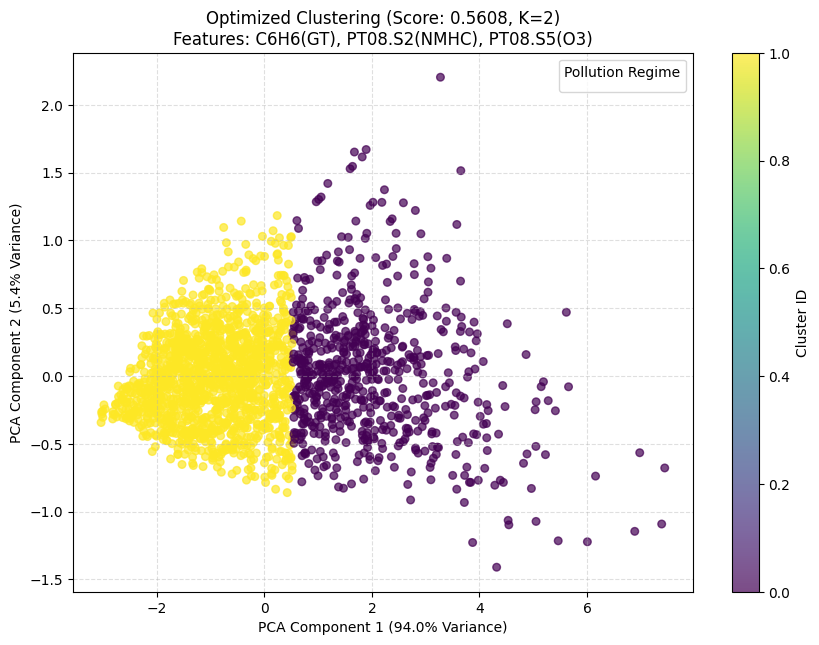

🚀 🎨 正在使用 TOP 1 配置尝试 t-SNE 降维可视化...


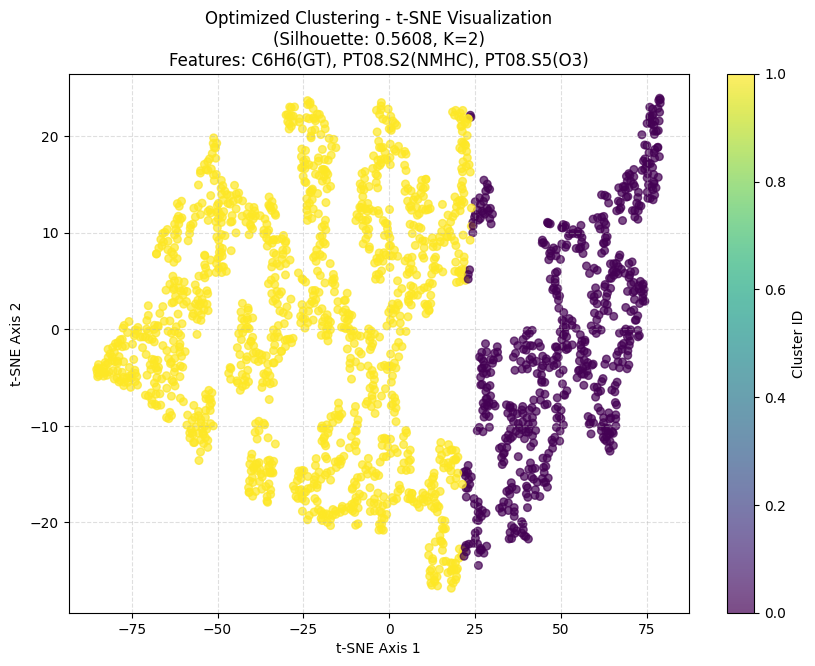

In [ ]:
# ==========================================
# 1. 数据准备
# ==========================================
file_path = r"D:\code\python\ML\Project\air+quality\AirQuality_Fully_Preprocessed.csv"
df = pd.read_csv(file_path)

# 采样 2000 个点，否则几百次循环跑得太慢
df_sampled = df.sample(n=2000, random_state=42).copy()

# 候选的 9 个化学污染特征池
all_features = [
    'CO(GT)', 'PT08.S1(CO)', 'C6H6(GT)', 'PT08.S2(NMHC)', 
    'NOx(GT)', 'PT08.S3(NOx)', 'NO2(GT)', 'PT08.S4(NO2)', 'PT08.S5(O3)'
]

X_full = df_sampled[all_features].copy()

# ==========================================
# 2. 暴力搜索 (Grid Search) 寻找最佳特征组合
# ==========================================
print("🚀 启动自动化特征筛选引擎...")
print(f"特征池总数: {len(all_features)}")

results = []
# 我们设定让机器只寻找包含 3 到 5 个特征的组合 (保证物理意义的同时降低噪音)
min_features = 3
max_features = 5

# K 值的探索范围 (通常 2 或 3 是空气质量的最佳切分)
k_range = [2, 3, 4]

# 计算总工作量用于进度提示
total_combinations = sum([len(list(itertools.combinations(all_features, r))) for r in range(min_features, max_features + 1)])
print(f"预计将评估 {total_combinations * len(k_range)} 种模型组合，请耐心等待数十秒...\n")

# 开始遍历
for r in range(min_features, max_features + 1):
    for combo in itertools.combinations(all_features, r):
        features_list = list(combo)
        
        # 提取子集并标准化
        X_sub = X_full[features_list]
        X_scaled = StandardScaler().fit_transform(X_sub)
        
        for k in k_range:
            # 运行 K-means
            kmeans = KMeans(n_clusters=k, init='k-means++', n_init=5, random_state=42)
            labels = kmeans.fit_predict(X_scaled)
            
            # 计算得分
            score = silhouette_score(X_scaled, labels)
            
            # 记录结果
            results.append({
                'K_Value': k,
                'Num_Features': r,
                'Silhouette_Score': score,
                'Features': features_list
            })

# ==========================================
# 3. 输出排行榜
# ==========================================
# 将结果转为 DataFrame 并按得分降序排列
df_results = pd.DataFrame(results).sort_values(by='Silhouette_Score', ascending=False)

print("="*60)
print(" 🏆 最佳聚类特征组合 TOP 5 排行榜")
print("="*60)
for i, row in df_results.head(5).iterrows():
    print(f"Top {list(df_results.index).index(i)+1}:")
    print(f" - 轮廓系数: {row['Silhouette_Score']:.4f}")
    print(f" - 最佳 K 值: {row['K_Value']}")
    print(f" - 使用了 {row['Num_Features']} 个特征: {', '.join(row['Features'])}\n")

# ==========================================
# 4. 用第一名的配置，画一张绝美的聚类图
# ==========================================
best_config = df_results.iloc[0]
best_features = best_config['Features']
best_k = best_config['K_Value']

print(f"🎨 正在使用 TOP 1 配置绘制 PCA 降维聚类图...")
X_best = X_full[best_features]
X_best_scaled = StandardScaler().fit_transform(X_best)

# 用第一名配置训练最终模型
final_kmeans = KMeans(n_clusters=best_k, init='k-means++', n_init=10, random_state=42)
best_labels = final_kmeans.fit_predict(X_best_scaled)

# 降维绘图
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_best_scaled)

plt.figure(figsize=(10, 7))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=best_labels, cmap='viridis', alpha=0.7, s=30)
plt.colorbar(scatter, label='Cluster ID')
plt.legend(title='Pollution Regime', fontsize=10)
plt.title(f'Optimized Clustering (Score: {best_config["Silhouette_Score"]:.4f}, K={best_k})\nFeatures: {", ".join(best_features)}', fontsize=12)
plt.xlabel(f'PCA Component 1 ({pca.explained_variance_ratio_[0]:.1%} Variance)')
plt.ylabel(f'PCA Component 2 ({pca.explained_variance_ratio_[1]:.1%} Variance)')
plt.grid(True, linestyle='--', alpha=0.4)
plt.show()


print(f"🚀 🎨 正在使用 TOP 1 配置尝试 t-SNE 降维可视化...")
# 注意：务必使用标准化后的最佳特征 X_best_scaled ！！！
# t-SNE 对随机种子很敏感，可以多换几个 random_state 试试
tsne = TSNE(n_components=2, perplexity=30, n_iter=1000, random_state=42)
X_tsne = tsne.fit_transform(X_best_scaled)

plt.figure(figsize=(10, 7))
# 依然使用刚才算好的 best_labels 进行着色
scatter = plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=best_labels, cmap='viridis', alpha=0.7, s=30)
plt.colorbar(scatter, label='Cluster ID')
plt.title(f'Optimized Clustering - t-SNE Visualization\n(Silhouette: {best_config["Silhouette_Score"]:.4f}, K={best_k})\nFeatures: {", ".join(best_features)}', fontsize=12)
plt.xlabel('t-SNE Axis 1')
plt.ylabel('t-SNE Axis 2')
plt.grid(True, linestyle='--', alpha=0.4)
plt.show()

In [ ]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn import metrics

# ==========================================
# 1. 准备优化后的数据 (Top 1 特征)
# ==========================================
# 提取你发现的最佳特征子集
best_features = ['C6H6(GT)', 'PT08.S2(NMHC)', 'PT08.S5(O3)']
X_best = df_sampled[best_features]

# 还原小时数用于外部交叉验证
hour_series = df_sampled.filter(like='H_').idxmax(axis=1).str.replace('H_', '').astype(int)
def categorize_time(hour):
    if 7 <= hour <= 10 or 17 <= hour <= 20: return 0  # 高峰期
    elif 11 <= hour <= 16: return 1                  # 白天平峰
    else: return 2                                    # 夜间/休息
y_true = hour_series.apply(categorize_time).values

# 标准化处理
scaler = StandardScaler()
X_best_scaled = scaler.fit_transform(X_best)

# ==========================================
# 2. 运行最佳配置 (K=2)
# ==========================================
# 这里的 K=2 是自动化筛选给出的最优解
kmeans_opt = KMeans(n_clusters=2, init='k-means++', n_init=10, random_state=42)
y_pred_opt = kmeans_opt.fit_predict(X_best_scaled)

# ==========================================
# 3. 深度指标报告
# ==========================================
print("="*60)
print(" 🚀 OPTIMIZED CLUSTERING (K=2, 3-FEATURES) REPORT")
print("="*60)

# --- 内部指标 (Internal) ---
print(f"[ Internal Metrics ]")
print(f"- Silhouette Score:    {metrics.silhouette_score(X_best_scaled, y_pred_opt):.4f} (显著提升)")
print(f"- Davies-Bouldin Index: {metrics.davies_bouldin_score(X_best_scaled, y_pred_opt):.4f} (越低越好)")
print(f"- Calinski-Harabasz:   {metrics.calinski_harabasz_score(X_best_scaled, y_pred_opt):.2f}")
print(f"- Inertia (WCSS):       {kmeans_opt.inertia_:.2f}")

# --- 外部指标 (External) ---
# 注意：即便化学聚类分得再好，与交通时段的匹配度（ARI/NMI）可能依然不高
# 这种“不匹配”本身就是一个重要的科学发现
print(f"\n[ External Metrics (vs Traffic Periods) ]")
print(f"- Adjusted Rand Index (ARI):    {metrics.adjusted_rand_score(y_true, y_pred_opt):.4f}")
print(f"- Normalized Mutual Info (NMI): {metrics.normalized_mutual_info_score(y_true, y_pred_opt):.4f}")
print(f"- V-Measure:                    {metrics.v_measure_score(y_true, y_pred_opt):.4f}")
print("="*60)

 🚀 OPTIMIZED CLUSTERING (K=2, 3-FEATURES) REPORT
[ Internal Metrics ]
- Silhouette Score:    0.5608 (显著提升)
- Davies-Bouldin Index: 0.6348 (越低越好)
- Calinski-Harabasz:   3462.72
- Inertia (WCSS):       2195.32

[ External Metrics (vs Traffic Periods) ]
- Adjusted Rand Index (ARI):    0.0822
- Normalized Mutual Info (NMI): 0.0672
- V-Measure:                    0.0672


🔬 正在进行多传感器信号融合 (GT + PT) ...

🚀 启动自动化特征筛选引擎...
融合后特征池总数: 5 ( CO_Fused, HC_Fused, NOx_Fused, NO2_Fused, O3_Fused )

 🏆 最佳【融合特征】聚类组合 TOP 5 排行榜
Top 1:
 - 轮廓系数: 0.5671
 - 最佳 K 值: 2
 - 使用了 2 个融合特征: CO_Fused, HC_Fused

Top 2:
 - 轮廓系数: 0.5580
 - 最佳 K 值: 2
 - 使用了 2 个融合特征: CO_Fused, O3_Fused

Top 3:
 - 轮廓系数: 0.5557
 - 最佳 K 值: 2
 - 使用了 2 个融合特征: HC_Fused, O3_Fused

Top 4:
 - 轮廓系数: 0.5532
 - 最佳 K 值: 2
 - 使用了 2 个融合特征: HC_Fused, NO2_Fused

Top 5:
 - 轮廓系数: 0.5423
 - 最佳 K 值: 2
 - 使用了 3 个融合特征: CO_Fused, HC_Fused, O3_Fused

🎨 正在绘制 PCA 降维聚类图...


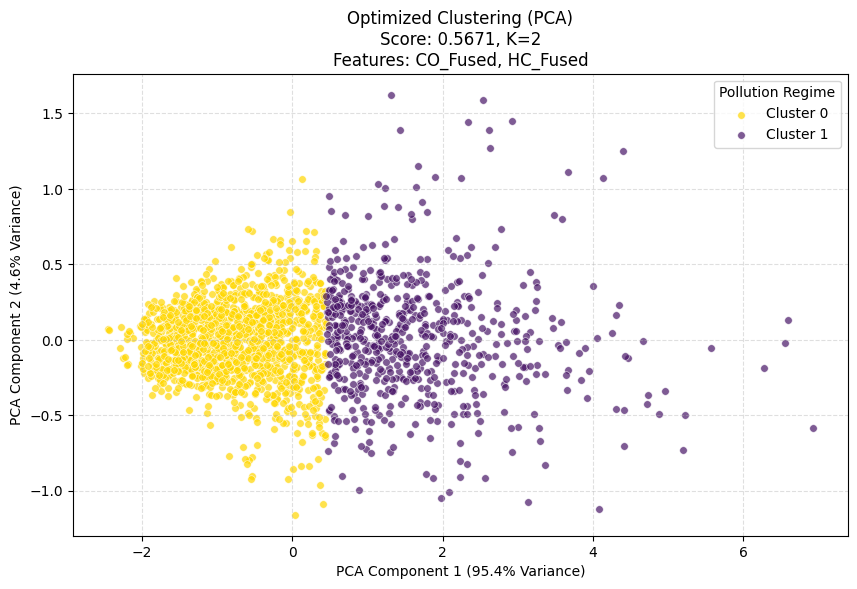

🚀 正在绘制 t-SNE 降维流形图 (请稍候)...


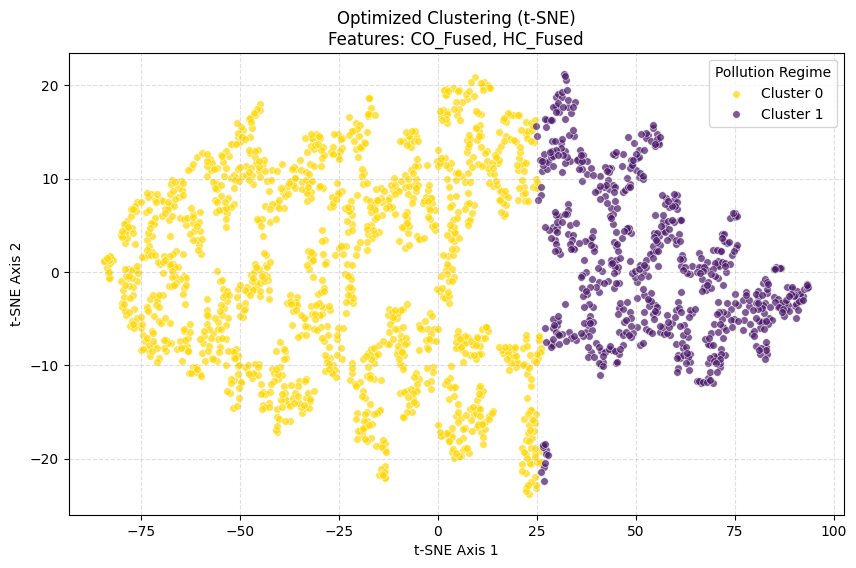

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import itertools
import warnings
warnings.filterwarnings('ignore')

# ==========================================
# 1. 数据准备 & 高级特征工程 (Sensor Fusion)
# ==========================================
file_path = r"D:\code\python\ML\Project\air+quality\AirQuality_Fully_Preprocessed.csv"
df = pd.read_csv(file_path)

df_sampled = df.sample(n=2000, random_state=42).copy()

print("🔬 正在进行多传感器信号融合 (GT + PT) ...")

# 定义需要融合的对子 (Benzene和NMHC通常反映同一类碳氢污染，所以归为一组)
fusion_pairs = {
    'CO_Fused': ['CO(GT)', 'PT08.S1(CO)'],
    'HC_Fused': ['C6H6(GT)', 'PT08.S2(NMHC)'], # HC = 碳氢化合物
    'NOx_Fused': ['NOx(GT)', 'PT08.S3(NOx)'],
    'NO2_Fused': ['NO2(GT)', 'PT08.S4(NO2)']
}

# 使用局部 PCA 提取每一对传感器的核心共性
for new_feat, pair in fusion_pairs.items():
    # 1. 先抹平量纲差异
    scaled_pair = StandardScaler().fit_transform(df_sampled[pair])
    # 2. 提取 1 维的最强共性信号
    pca_fusion = PCA(n_components=1)
    df_sampled[new_feat] = pca_fusion.fit_transform(scaled_pair)[:, 0]

# O3 只有传感器读数，没有对应的 GT 浓度，所以单独拿出来并标准化
df_sampled['O3_Fused'] = StandardScaler().fit_transform(df_sampled[['PT08.S5(O3)']])[:, 0]

# 这是我们全新的、经过融合浓缩的特征池！
all_features = ['CO_Fused', 'HC_Fused', 'NOx_Fused', 'NO2_Fused', 'O3_Fused']
X_full = df_sampled[all_features].copy()


# ==========================================
# 2. 暴力搜索 (Grid Search) 寻找最佳融合特征组合
# ==========================================
print("\n🚀 启动自动化特征筛选引擎...")
print(f"融合后特征池总数: {len(all_features)} ( {', '.join(all_features)} )")

results = []
# 因为总特征只有5个了，我们搜索 2 到 4 个组合
min_features = 2
max_features = 4
k_range = [2, 3, 4]

# 开始遍历
for r in range(min_features, max_features + 1):
    for combo in itertools.combinations(all_features, r):
        features_list = list(combo)
        
        # 提取子集并标准化 (虽然前面融合时做过，但保险起见整体再标准化一次)
        X_sub = X_full[features_list]
        X_scaled = StandardScaler().fit_transform(X_sub)
        
        for k in k_range:
            kmeans = KMeans(n_clusters=k, init='k-means++', n_init=5, random_state=42)
            labels = kmeans.fit_predict(X_scaled)
            score = silhouette_score(X_scaled, labels)
            
            results.append({
                'K_Value': k,
                'Num_Features': r,
                'Silhouette_Score': score,
                'Features': features_list
            })

# ==========================================
# 3. 输出排行榜
# ==========================================
df_results = pd.DataFrame(results).sort_values(by='Silhouette_Score', ascending=False)

print("\n" + "="*60)
print(" 🏆 最佳【融合特征】聚类组合 TOP 5 排行榜")
print("="*60)
for i, row in df_results.head(5).iterrows():
    print(f"Top {list(df_results.index).index(i)+1}:")
    print(f" - 轮廓系数: {row['Silhouette_Score']:.4f}")
    print(f" - 最佳 K 值: {row['K_Value']}")
    print(f" - 使用了 {row['Num_Features']} 个融合特征: {', '.join(row['Features'])}\n")

# ==========================================
# 4. 绘制双料可视化 (PCA + t-SNE) 
# ==========================================
best_config = df_results.iloc[0]
best_features = best_config['Features']
best_k = best_config['K_Value']

X_best = X_full[best_features]
X_best_scaled = StandardScaler().fit_transform(X_best)

final_kmeans = KMeans(n_clusters=best_k, init='k-means++', n_init=10, random_state=42)
best_labels = final_kmeans.fit_predict(X_best_scaled)

# --- 绘图 1: PCA ---
print(f"🎨 正在绘制 PCA 降维聚类图...")
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_best_scaled)

plt.figure(figsize=(10, 6))
# 修复了连续 Colorbar 的问题，改为离散的图例
unique_labels = np.unique(best_labels)
colors = ['#FFD700', '#481567', '#2E8B57', '#CD5C5C'][:best_k] 
for i, label in enumerate(unique_labels):
    idx = best_labels == label
    plt.scatter(X_pca[idx, 0], X_pca[idx, 1], c=colors[i], label=f'Cluster {label}', alpha=0.7, s=30, edgecolors='w', linewidth=0.5)

plt.legend(title='Pollution Regime', fontsize=10)
plt.title(f'Optimized Clustering (PCA)\nScore: {best_config["Silhouette_Score"]:.4f}, K={best_k}\nFeatures: {", ".join(best_features)}', fontsize=12)
plt.xlabel(f'PCA Component 1 ({pca.explained_variance_ratio_[0]:.1%} Variance)')
plt.ylabel(f'PCA Component 2 ({pca.explained_variance_ratio_[1]:.1%} Variance)')
plt.grid(True, linestyle='--', alpha=0.4)
plt.show()

# --- 绘图 2: t-SNE ---
print(f"🚀 正在绘制 t-SNE 降维流形图 (请稍候)...")
tsne = TSNE(n_components=2, perplexity=30, n_iter=1000, random_state=42, init='pca')
X_tsne = tsne.fit_transform(X_best_scaled)

plt.figure(figsize=(10, 6))
for i, label in enumerate(unique_labels):
    idx = best_labels == label
    plt.scatter(X_tsne[idx, 0], X_tsne[idx, 1], c=colors[i], label=f'Cluster {label}', alpha=0.7, s=30, edgecolors='w', linewidth=0.5)

plt.legend(title='Pollution Regime', fontsize=10)
plt.title(f'Optimized Clustering (t-SNE)\nFeatures: {", ".join(best_features)}', fontsize=12)
plt.xlabel('t-SNE Axis 1')
plt.ylabel('t-SNE Axis 2')
plt.grid(True, linestyle='--', alpha=0.4)
plt.show()